In [1]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import pandas as pd 
%matplotlib inline

## Load Data set 

customer segmentation data ... 900 customers, 8 features
some features are correlated on purpose ( loyalty_points and estimated_ltv depend on other cols )
so PCA has something real to compress

In [ ]:
df = pd.read_csv("customer_segmentation.csv")
df

,age,annual_income,spending_score,purchase_frequency,avg_transaction,days_since_purchase,loyalty_points,estimated_ltv
0,26,28098.0,35.0,3.2,509.13,72,873,1495.76
1,51,156981.0,78.2,12.5,2979.87,9,3806,37663.85
2,26,21354.0,17.7,3.6,481.57,55,695,1979.52
3,37,72122.0,62.6,5.7,1043.07,35,1773,5670.14
4,26,25745.0,14.6,2.2,562.84,17,617,1189.73
...,...,...,...,...,...,...,...,...
895,33,23730.0,14.8,4.3,402.82,62,587,1708.23
896,31,28074.0,23.6,4.1,519.66,61,1018,2084.07
897,45,130192.0,94.5,10.2,3047.41,8,3255,31189.19
898,31,70846.0,52.0,7.4,1310.75,32,1745,9954.82


In [3]:
df.shape

(900, 8)

In [4]:
df.describe()

,age,annual_income,spending_score,purchase_frequency,avg_transaction,days_since_purchase,loyalty_points,estimated_ltv
count,900.00000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,37.42000,74117.493333,55.104556,8.376778,1602.779244,31.312222,1897.413333,18529.878989
std,10.84614,43233.049617,25.375594,4.935130,1228.472116,24.179926,1092.920850,20229.044301
min,18.00000,18113.000000,3.400000,0.000000,140.900000,0.000000,345.000000,0.000000
25%,27.00000,30482.500000,30.700000,4.000000,471.627500,10.000000,817.500000,1812.635000
50%,39.00000,65055.500000,55.800000,7.800000,1196.865000,25.000000,1691.500000,9137.915000
75%,46.00000,120518.250000,78.800000,12.200000,2849.455000,51.000000,3051.000000,36306.865000
max,70.00000,177281.000000,100.000000,22.300000,4756.460000,108.000000,4367.000000,84717.270000


In [5]:
df.isnull().sum()
# clean dataset, no nulls to handle here

age                    0
annual_income          0
spending_score         0
purchase_frequency     0
avg_transaction        0
days_since_purchase    0
loyalty_points         0
estimated_ltv          0
dtype: int64

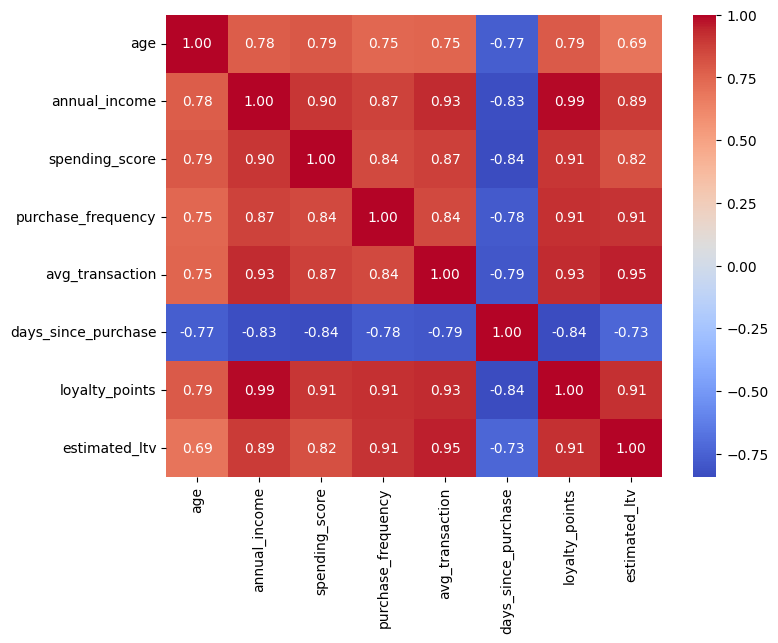

In [6]:
# quick look at correlation before PCA
# see which features are related to each other
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

AS I am applying Un-supervised learning ... means we don't need the Output
we dont have a target col here anyway, just raw features to cluster on

___
# train test split 
___

In [ ]:
from sklearn.model_selection import train_test_splitfrom sklearn.model_selection import train_test_split

In [8]:
X_train, X_test = train_test_split(df, test_size = 0.25, random_state = 43)

In [9]:
X_train.shape, X_test.shape

((675, 8), (225, 8))

___
# Standardization 
___

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()

In [12]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # transform only, not fit_transform ( no leakage )

In [13]:
X_train_scaled

array([[-1.41279794, -1.04668449, -1.21276755, ...,  0.81589317,
        -1.12121625, -0.90272243],
       [-1.13614038, -0.87510998, -1.6526525 , ...,  1.64711783,
        -0.86161142, -0.80063478],
       [-0.39838689,  1.52612657,  1.13847587, ..., -1.05436229,
         1.28081166,  0.46644986],
       ...,
       [-1.78167469, -1.1409053 , -0.78456097, ...,  0.69120948,
        -0.99278018, -0.8453935 ],
       [-0.12172933, -0.24625694, -0.37192553, ..., -0.4309438 ,
        -0.05364829, -0.42391623],
       [-1.78167469, -0.99142856, -1.5319761 , ...,  0.02622976,
        -0.83883906, -0.77708575]], shape=(675, 8))

___
# Applying PCA 
___

In [14]:
from sklearn.decomposition import PCA

In [ ]:
 # first fit PCA with no n_components to see how much variance each PC explains 
pca_full = PCA()
pca_full.fit(X_train_scaled)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [16]:
pca_full.explained_variance_ratio_

array([8.65632831e-01, 5.17117529e-02, 2.87749055e-02, 2.15301839e-02,
       1.66084131e-02, 1.32889135e-02, 1.86852373e-03, 5.84476526e-04])

In [17]:
# cumulative variance, helps decide how many components to keep
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
cumulative_variance

array([0.86563283, 0.91734458, 0.94611949, 0.96764967, 0.98425809,
       0.997547  , 0.99941552, 1.        ])

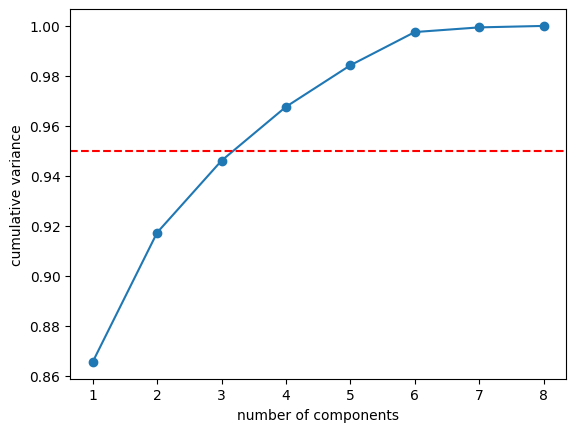

In [18]:
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker="o")
plt.xlabel("number of components")
plt.ylabel("cumulative variance")
plt.axhline(y=0.95, color="r", linestyle="--")
plt.show()

# see where the curve crosses the red line ( 95% variance ) 
# that many components is enough, dont need all 8

In [19]:
 # now apply PCA keeping 95% variance instead of guessing number of components
pca = PCA(n_components = 0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)   # transform only on test

In [20]:
X_train_pca.shape
# see, features reduced from 8 down to fewer components, still 95% info kept

(675, 4)

In [21]:
pca.explained_variance_ratio_

array([0.86563283, 0.05171175, 0.02877491, 0.02153018])

___
# Model Training — KMeans on PCA data
___

In [22]:
from sklearn.cluster import KMeans

Elbow method to Select K value

In [23]:
wcss = []
for k in range(1,11):
    model = KMeans(n_clusters = k, init = "k-means++", random_state = 42)
    model.fit(X_train_pca)
    wcss.append(model.inertia_) # wcss is stored in inertia_ method

In [24]:
wcss

[5225.308234955353,
 1485.691989856652,
 545.6210369104831,
 457.72621877889014,
 411.8519942788391,
 369.1654423203696,
 359.00957360261384,
 311.66261925626617,
 292.2741747396822,
 280.83894897165834]

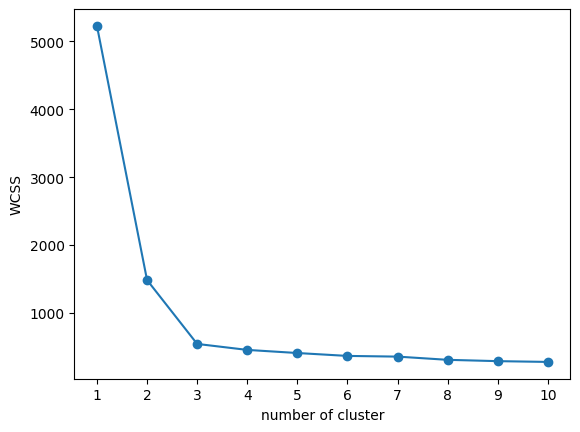

In [25]:
# Plot Elbow Curve 
plt.plot(range(1,11), wcss, marker="o")
plt.xticks(range(1,11))
plt.xlabel("number of cluster")
plt.ylabel("WCSS")
plt.show()

Find region where Value knuckle down and then becomes stable
looks like 3 is that point

In [26]:
kmeans = KMeans(n_clusters = 3, init="k-means++", random_state = 42)

kmeans.fit_predict(X_train_pca)

array([2, 2, 0, 1, 0, 1, 1, 1, 2, 0, 1, 1, 1, 2, 2, 2, 1, 1, 0, 2, 1, 0,
       1, 2, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 1, 1, 1, 0, 1, 1, 0,
       2, 0, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 1, 0, 1, 1, 2, 2, 1, 0, 2, 1,
       2, 0, 0, 1, 2, 2, 1, 0, 1, 2, 0, 2, 2, 1, 0, 2, 1, 2, 0, 2, 2, 2,
       0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 2, 1, 2, 0, 0, 2, 1, 2, 0, 1, 2,
       2, 2, 2, 1, 0, 2, 2, 1, 2, 0, 0, 0, 2, 1, 2, 2, 0, 1, 2, 1, 0, 0,
       2, 2, 1, 2, 0, 1, 2, 1, 1, 2, 1, 0, 0, 1, 2, 2, 1, 2, 2, 0, 1, 2,
       2, 2, 1, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 0, 0, 2, 1, 2, 2, 0, 0, 0,
       0, 1, 0, 2, 1, 1, 1, 1, 0, 2, 2, 2, 1, 2, 1, 1, 2, 0, 0, 2, 2, 2,
       0, 2, 2, 1, 2, 1, 0, 1, 1, 0, 1, 1, 2, 1, 0, 2, 1, 0, 1, 1, 2, 0,
       2, 2, 0, 2, 1, 1, 0, 0, 0, 2, 1, 1, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1,
       2, 0, 1, 0, 2, 0, 1, 0, 1, 2, 0, 1, 2, 0, 0, 2, 1, 1, 0, 2, 2, 0,
       1, 1, 1, 0, 1, 0, 2, 0, 0, 2, 2, 2, 1, 0, 0, 1, 1, 0, 1, 0, 1, 2,
       1, 2, 2, 0, 2, 2, 0, 1, 1, 0, 0, 1, 0, 0, 2,

In [27]:
y_pred = kmeans.predict(X_test_pca)

In [28]:
y_pred

array([1, 0, 2, 1, 2, 1, 2, 0, 1, 0, 0, 2, 0, 0, 2, 2, 1, 2, 0, 0, 0, 0,
       1, 2, 0, 0, 1, 2, 0, 1, 0, 0, 0, 0, 0, 2, 1, 0, 0, 2, 1, 0, 1, 0,
       2, 0, 2, 1, 2, 2, 2, 0, 0, 0, 1, 1, 2, 2, 2, 0, 0, 1, 0, 2, 0, 2,
       1, 1, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 2,
       1, 2, 0, 1, 2, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, 1, 2, 0, 1, 1, 0, 0,
       2, 0, 1, 1, 2, 1, 2, 1, 0, 2, 0, 1, 1, 2, 2, 0, 1, 1, 0, 1, 2, 0,
       1, 2, 0, 2, 2, 0, 1, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 1, 2, 2, 2, 1,
       0, 0, 0, 1, 2, 1, 2, 0, 2, 1, 0, 0, 0, 2, 2, 0, 2, 0, 1, 1, 1, 0,
       1, 1, 2, 0, 0, 0, 0, 2, 1, 2, 1, 0, 1, 0, 0, 0, 0, 1, 2, 2, 0, 1,
       2, 1, 1, 0, 0, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 2, 0,
       2, 1, 1, 2, 2], dtype=int32)

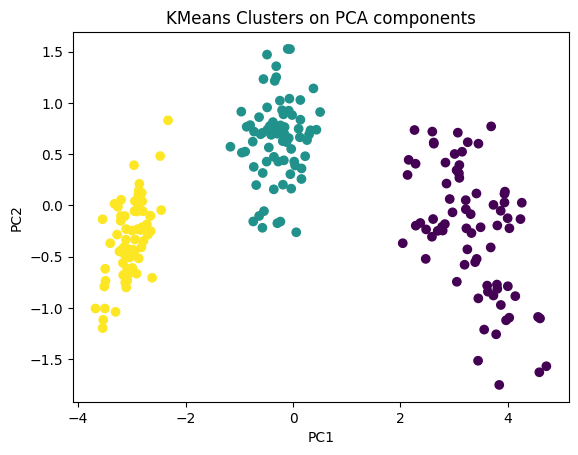

In [29]:
# plot it, PC1 vs PC2 ( not same column this time )
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c = y_pred)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters on PCA components")
plt.show()

___
# Cluster Profiling
___
see what each cluster actually means in terms of original features
attach predicted cluster back to the ORIGINAL unscaled test data

In [30]:
X_test_profiled = X_test.copy()
X_test_profiled["cluster"] = y_pred
X_test_profiled.head()

,age,annual_income,spending_score,purchase_frequency,avg_transaction,days_since_purchase,loyalty_points,estimated_ltv,cluster
357,42,57810.0,41.2,6.8,1023.09,24,1790,6502.51,1
276,42,153382.0,76.5,15.2,3204.39,5,3781,49456.43,0
830,29,29968.0,34.3,0.0,649.30,16,698,0.00,2
433,38,65835.0,59.3,5.8,1317.51,16,1552,7187.58,1
895,33,23730.0,14.8,4.3,402.82,62,587,1708.23,2


In [31]:
X_test_profiled.groupby("cluster").mean()
# compare rows, this tells us what each cluster means in plain business terms

,age,annual_income,spending_score,purchase_frequency,avg_transaction,days_since_purchase,loyalty_points,estimated_ltv
cluster,,,,,,,,
0,47.918919,128677.256757,82.324324,14.252703,3198.391081,7.608108,3265.472973,45752.722162
1,40.263158,65105.355263,55.411842,7.992105,1205.615789,24.802632,1694.236842,9674.096579
2,25.080000,27954.280000,25.689333,2.974667,409.621467,60.786667,713.133333,1153.057867


In [32]:
X_test_profiled["cluster"].value_counts()

cluster
1    76
2    75
0    74
Name: count, dtype: int64

## Findings

cluster with low annual_income + low spending_score + high days_since_purchase → budget / low engagement customers
cluster with mid income + mid spending_score + regular purchase_frequency → regular shoppers
cluster with high income + high spending_score + low days_since_purchase → premium spenders

PCA reduced 8 features down to fewer components while keeping 95% of the variance
KMeans on the PCA components still separated the 3 groups cleanly
so PCA + KMeans together worked well here, didn't lose the signal that mattered